# V37: LQ45 AI Strategy - Moving Average (MA) as Prediction Target

In this version, we move away from predicting noisy daily returns. Instead, the AI is trained to predict the **Direction of the Trend** based on Moving Averages.

### Target Logic (MA Slope):
- **Target = 1 (Bullish Trend)**: If the 5-day Moving Average ($SMA_5$) tomorrow is higher than today.
- **Target = 0 (Bearish/Flat Trend)**: If the 5-day Moving Average stays same or decreases.

### Why use MA as a target?
- **Noise Reduction**: It filters out daily price spikes that don't represent a real trend change.
- **Reduced Turnover**: Leads to steadier signals, which significantly reduces transaction costs in the stock market.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. MA-Based Labeling & Feature Engineering ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()

# Reference MAs
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()

# Input Features (Distance to MA)
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# NEW TARGET: Predicting if the 5-day trend is turning UP tomorrow
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

print("Training AI to predict Trend Slope Changes...")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Threshold Optimization (TP/FP Ratio)
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.40, 0.71, 0.01)
ratios = []
for t in thresholds:
    preds = (train_probs >= t).astype(int)
    if np.sum(preds) == 0: ratios.append(0); continue
    tn, fp, fn, tp = confusion_matrix(y_train, preds).ravel()
    ratios.append(tp / fp if fp > 0 else tp)

opt_t = thresholds[np.argmax(ratios)]
print(f"Optimized Threshold for MA-Target: {opt_t:.2f}")

Training AI to predict Trend Slope Changes...
Optimized Threshold for MA-Target: 0.70


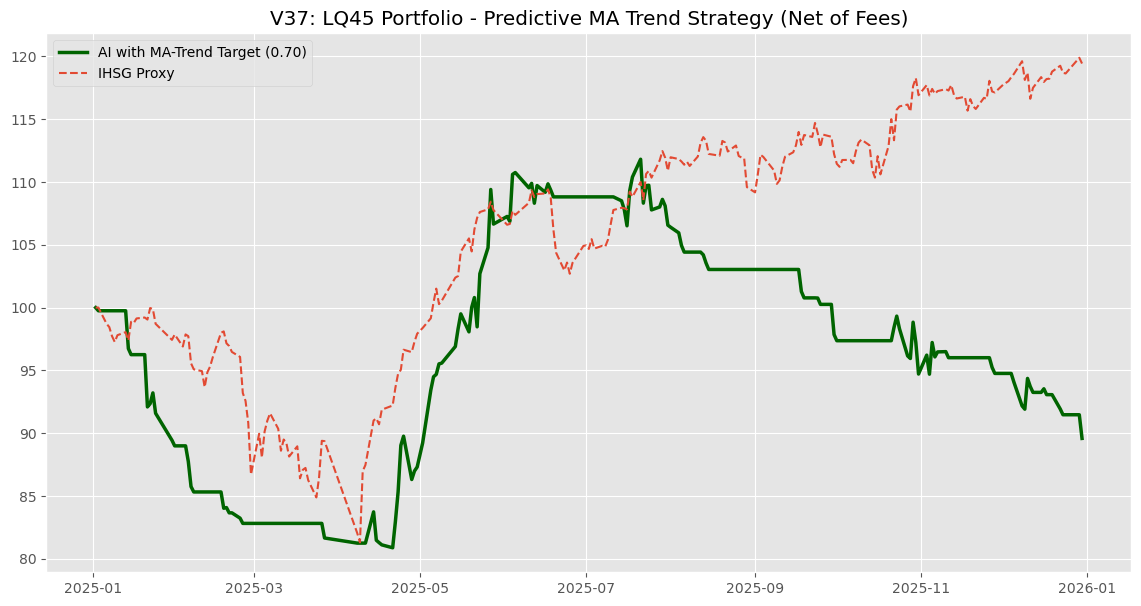

In [3]:
# --- 3. Run Simulation (0.25% Transaction Fees) ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold: G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', bounds=tuple((0, 1) for _ in range(len(mu))), constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(test_dates, returns, ai_probs, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    for i, date in enumerate(test_dates[:-1]):
        is_risk_off = ai_probs.loc[date] < threshold
        if is_risk_off: weights = {'CASH': 1.0}
        else:
            loc_idx = returns.index.get_loc(date)
            window_rets = returns.iloc[loc_idx-30:loc_idx]
            selected = get_mis_assets(window_rets)
            weights = optimize_markowitz(window_rets[selected])
        
        # Transaction Taxes/Fees
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

test_dates = X_test.index
probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=test_dates)
res_ma_target = run_simulation(test_dates, returns, probs, threshold=opt_t)
benchmark = pd.DataFrame({'Portfolio_Value': (market_price.loc[test_dates] / market_price.loc[test_dates[0]] * 100)}, index=test_dates)

plt.figure(figsize=(14, 7))
plt.plot(res_ma_target.index, res_ma_target['Portfolio_Value'], label=f"AI with MA-Trend Target ({opt_t:.2f})", color='darkgreen', linewidth=2.5)
plt.plot(benchmark.index, benchmark['Portfolio_Value'], label="IHSG Proxy", linestyle='--')
plt.title("V37: LQ45 Portfolio - Predictive MA Trend Strategy (Net of Fees)")
plt.legend()
plt.show()